# 🇮🇳 India Tech Brain Drain Decoder
**Are Indian developers being valued for their skills — or leaving to find better pay abroad?**

This project uses the Stack Overflow Developer Survey 2024 to analyze:
- Salary gaps between Indian devs and global counterparts
- Which programming languages close the gap the most
- Education vs salary impact
- Remote work trends among Indian developers

## Phase 1 — Load & Explore the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor':   '#1a1a1a',
    'axes.edgecolor':   '#333333',
    'axes.labelcolor':  '#cccccc',
    'xtick.color':      '#999999',
    'ytick.color':      '#999999',
    'text.color':       '#cccccc',
    'grid.color':       '#2a2a2a',
    'grid.linewidth':   0.6,
    'font.family':      'sans-serif',
    'font.size':        11,
})
ACCENT   = '#00d4aa'   # teal
INDIA    = '#ff6b35'   # orange
GLOBAL   = '#4a9eff'   # blue
HIGHLIGHT= '#ffd166'   # yellow

print('Libraries loaded ✅')

Libraries loaded ✅


In [2]:
# ── Load the dataset ───────────────────────────────────
# Make sure results.csv is in the same folder as this notebook
df = pd.read_csv('results.csv', low_memory=False)

print(f'Total responses: {len(df):,}')
print(f'Total columns:   {df.shape[1]}')
print(f'\nKey columns available:')
key_cols = ['Country', 'ConvertedCompYearly', 'LanguageHaveWorkedWith',
            'EdLevel', 'Employment', 'RemoteWork', 'YearsCodePro', 'DevType']
for c in key_cols:
    print(f'  ✓ {c}' if c in df.columns else f'  ✗ {c} (not found)')

Total responses: 65,437
Total columns:   114

Key columns available:
  ✓ Country
  ✓ ConvertedCompYearly
  ✓ LanguageHaveWorkedWith
  ✓ EdLevel
  ✓ Employment
  ✓ RemoteWork
  ✓ YearsCodePro
  ✓ DevType


## Phase 2 — Clean & Filter

In [3]:
# ── Keep only relevant columns ─────────────────────────
cols = ['Country', 'ConvertedCompYearly', 'LanguageHaveWorkedWith',
        'EdLevel', 'Employment', 'RemoteWork', 'YearsCodePro', 'DevType']
df = df[[c for c in cols if c in df.columns]].copy()

# ── Remove non-employed / students / no salary ─────────
df = df[df['Employment'].str.contains('Employed, full-time', na=False)]
df = df.dropna(subset=['ConvertedCompYearly', 'Country'])

# ── Remove extreme outliers (keep $5k – $500k) ─────────
df = df[(df['ConvertedCompYearly'] >= 5_000) &
        (df['ConvertedCompYearly'] <= 500_000)]

# ── Tag India vs Rest of World ─────────────────────────
df['Region'] = df['Country'].apply(lambda x: 'India' if x == 'India' else 'Global')

india_df  = df[df['Region'] == 'India']
global_df = df[df['Region'] == 'Global']

print(f'India responses:  {len(india_df):,}')
print(f'Global responses: {len(global_df):,}')
print(f'\nIndia median salary: ${india_df["ConvertedCompYearly"].median():,.0f}')
print(f'Global median salary: ${global_df["ConvertedCompYearly"].median():,.0f}')

India responses:  806
Global responses: 18,240

India median salary: $21,092
Global median salary: $74,052


## Phase 3 — Analysis & Visualizations

### Chart 1 — Salary Distribution: India vs Global

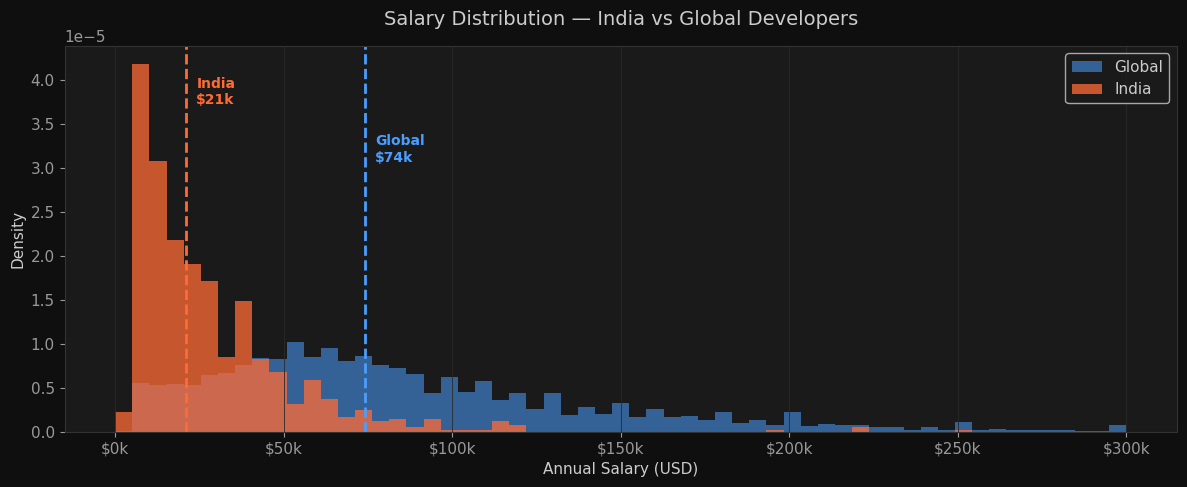

Saved: chart1_salary_distribution.png


In [4]:
fig, ax = plt.subplots(figsize=(12, 5))

bins = np.linspace(0, 300_000, 60)

ax.hist(global_df['ConvertedCompYearly'], bins=bins,
        color=GLOBAL, alpha=0.55, label='Global', density=True)
ax.hist(india_df['ConvertedCompYearly'], bins=bins,
        color=INDIA, alpha=0.75, label='India', density=True)

# Median lines
india_med  = india_df['ConvertedCompYearly'].median()
global_med = global_df['ConvertedCompYearly'].median()
ax.axvline(india_med,  color=INDIA,  linewidth=2, linestyle='--')
ax.axvline(global_med, color=GLOBAL, linewidth=2, linestyle='--')

ax.text(india_med  + 3000, ax.get_ylim()[1]*0.85, f'India\n${india_med/1000:.0f}k',
        color=INDIA,  fontsize=10, fontweight='bold')
ax.text(global_med + 3000, ax.get_ylim()[1]*0.70, f'Global\n${global_med/1000:.0f}k',
        color=GLOBAL, fontsize=10, fontweight='bold')

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.set_xlabel('Annual Salary (USD)')
ax.set_ylabel('Density')
ax.set_title('Salary Distribution — India vs Global Developers', fontsize=14, pad=15)
ax.legend()
ax.grid(True, axis='x')
plt.tight_layout()
plt.savefig('chart1_salary_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart1_salary_distribution.png')

### Chart 2 — Which Languages Close the Pay Gap?

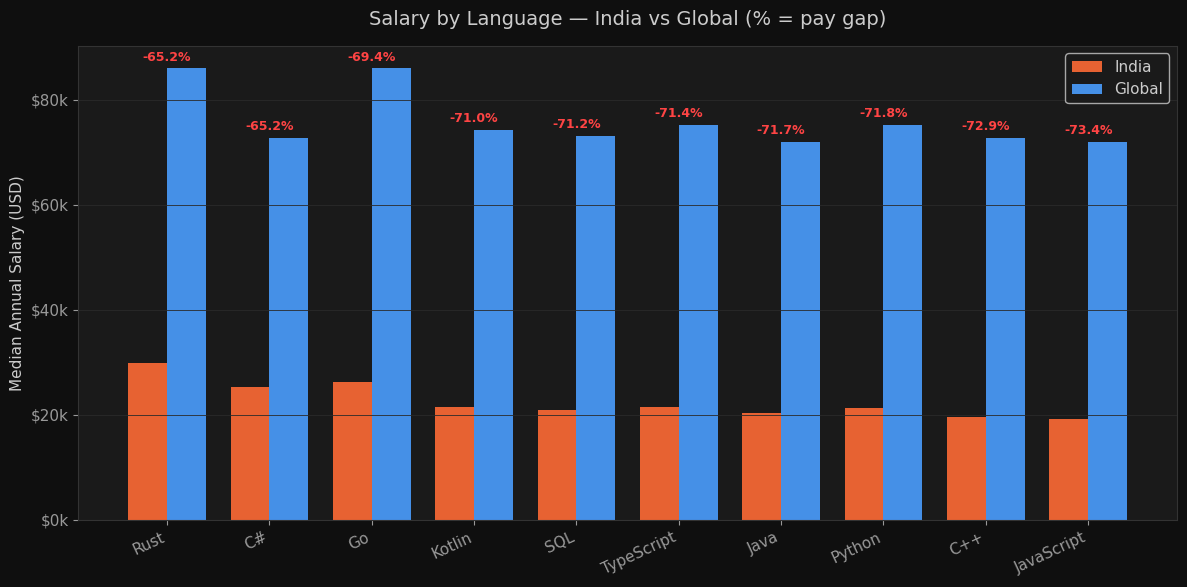

Saved: chart2_language_gap.png


In [5]:
TOP_LANGS = ['Python', 'JavaScript', 'TypeScript', 'Java', 'Go',
             'Rust', 'Kotlin', 'SQL', 'C#', 'C++']

rows = []
for lang in TOP_LANGS:
    i_med = india_df[india_df['LanguageHaveWorkedWith'].str.contains(lang, na=False)]['ConvertedCompYearly'].median()
    g_med = global_df[global_df['LanguageHaveWorkedWith'].str.contains(lang, na=False)]['ConvertedCompYearly'].median()
    if pd.notna(i_med) and pd.notna(g_med) and g_med > 0:
        rows.append({'Language': lang, 'India': i_med, 'Global': g_med,
                     'Gap%': round((1 - i_med / g_med) * 100, 1)})

lang_df = pd.DataFrame(rows).sort_values('Gap%')

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(lang_df))
w = 0.38

b1 = ax.bar(x - w/2, lang_df['India'],  width=w, color=INDIA,  label='India',  alpha=0.9)
b2 = ax.bar(x + w/2, lang_df['Global'], width=w, color=GLOBAL, label='Global', alpha=0.9)

# Gap % labels on top
for i, row in lang_df.reset_index().iterrows():
    color = HIGHLIGHT if row['Gap%'] < 50 else '#ff4444'
    ax.text(i, max(row['India'], row['Global']) + 1500,
            f"-{row['Gap%']}%", ha='center', fontsize=9, color=color, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(lang_df['Language'], rotation=25, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.set_ylabel('Median Annual Salary (USD)')
ax.set_title('Salary by Language — India vs Global (% = pay gap)', fontsize=14, pad=15)
ax.legend()
ax.grid(True, axis='y')
plt.tight_layout()
plt.savefig('chart2_language_gap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart2_language_gap.png')

### Chart 3 — Education vs Salary in India

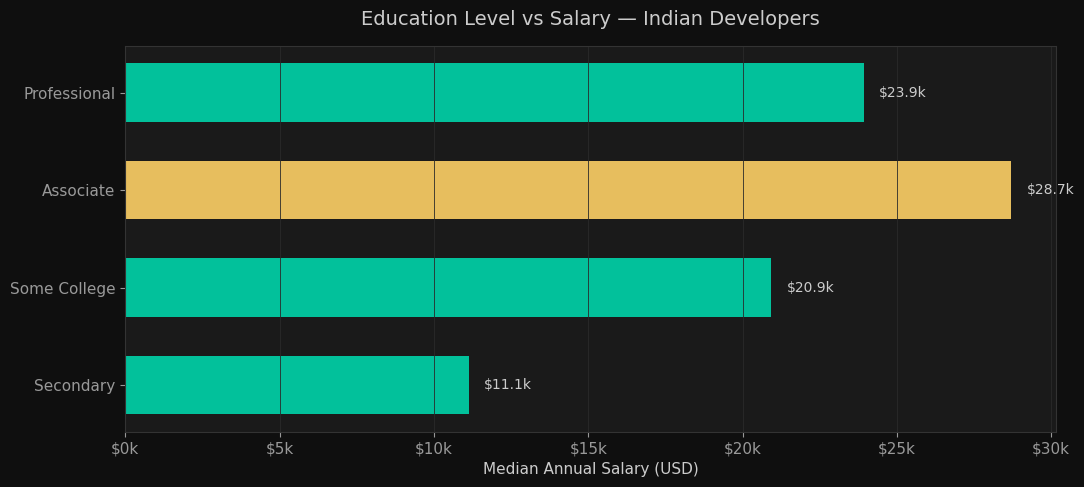

Saved: chart3_education_salary.png


In [6]:
ed_map = {
    'Primary/elementary school': 'Primary',
    'Secondary school': 'Secondary',
    'Some college/university study without earning a degree': 'Some College',
    "Bachelor's degree": "Bachelor's",
    "Master's degree": "Master's",
    'Professional degree': 'Professional',
    'Associate degree': 'Associate',
    'Other doctoral degree': 'PhD',
}

india_ed = india_df.copy()
for full, short in ed_map.items():
    india_ed.loc[india_ed['EdLevel'].str.contains(full, na=False), 'EdShort'] = short
india_ed = india_ed.dropna(subset=['EdShort'])

order = ['Secondary', 'Some College', "Bachelor's", 'Associate', "Master's", 'Professional', 'PhD']
order = [o for o in order if o in india_ed['EdShort'].unique()]

medians = india_ed.groupby('EdShort')['ConvertedCompYearly'].median().reindex(order)
colors  = [HIGHLIGHT if v == medians.max() else ACCENT for v in medians.values]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(medians.index, medians.values, color=colors, alpha=0.9, height=0.6)

for bar, val in zip(bars, medians.values):
    ax.text(val + 500, bar.get_y() + bar.get_height()/2,
            f'${val/1000:.1f}k', va='center', fontsize=10)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.set_xlabel('Median Annual Salary (USD)')
ax.set_title('Education Level vs Salary — Indian Developers', fontsize=14, pad=15)
ax.grid(True, axis='x')
plt.tight_layout()
plt.savefig('chart3_education_salary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart3_education_salary.png')

### Chart 4 — Experience vs Salary: India vs Global

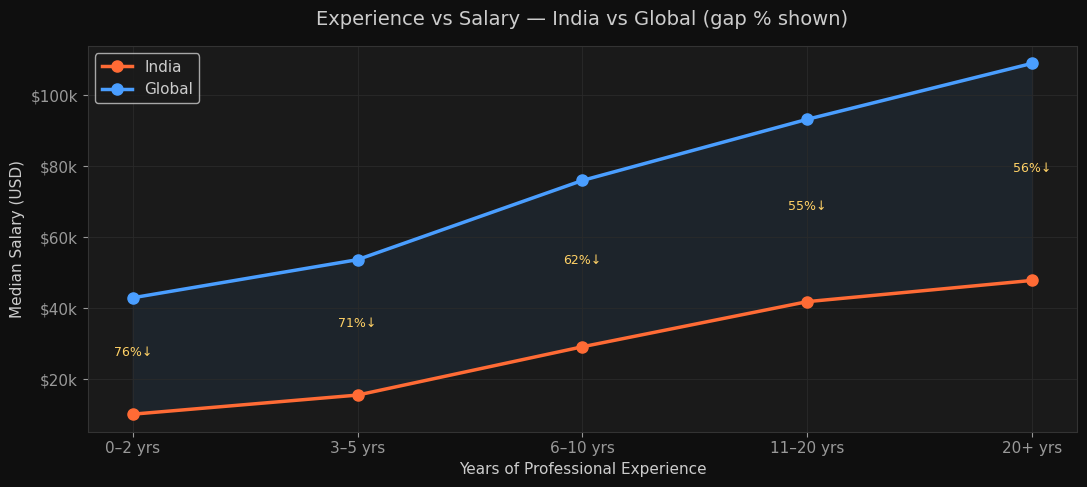

Saved: chart4_experience_salary.png


In [7]:
def exp_bucket(v):
    try:
        v = float(v)
        if v <= 2:   return '0–2 yrs'
        elif v <= 5: return '3–5 yrs'
        elif v <= 10:return '6–10 yrs'
        elif v <= 20:return '11–20 yrs'
        else:        return '20+ yrs'
    except: return None

df['ExpBucket'] = df['YearsCodePro'].apply(exp_bucket)
exp_order = ['0–2 yrs', '3–5 yrs', '6–10 yrs', '11–20 yrs', '20+ yrs']

exp_india  = df[df['Region']=='India'].groupby('ExpBucket')['ConvertedCompYearly'].median().reindex(exp_order)
exp_global = df[df['Region']=='Global'].groupby('ExpBucket')['ConvertedCompYearly'].median().reindex(exp_order)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(exp_order, exp_india.values,  'o-', color=INDIA,  linewidth=2.5, markersize=8, label='India')
ax.plot(exp_order, exp_global.values, 'o-', color=GLOBAL, linewidth=2.5, markersize=8, label='Global')

ax.fill_between(exp_order, exp_india.values, exp_global.values, alpha=0.08, color=GLOBAL)

for i, (iv, gv) in enumerate(zip(exp_india.values, exp_global.values)):
    if pd.notna(iv) and pd.notna(gv):
        gap = (1 - iv/gv)*100
        ax.text(i, (iv+gv)/2, f'{gap:.0f}%↓', ha='center', fontsize=9, color=HIGHLIGHT)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.set_xlabel('Years of Professional Experience')
ax.set_ylabel('Median Salary (USD)')
ax.set_title('Experience vs Salary — India vs Global (gap % shown)', fontsize=14, pad=15)
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('chart4_experience_salary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart4_experience_salary.png')

### Chart 5 — Remote Work: Does It Help Indian Devs Earn More?

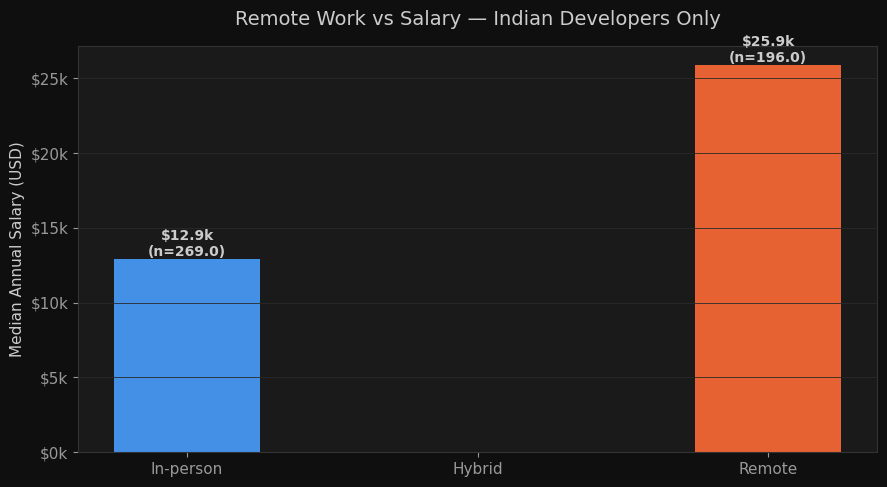

Saved: chart5_remote_salary.png


In [8]:
remote_map = {
    'Remote': 'Remote',
    'Hybrid': 'Hybrid',
    'In-person': 'In-person'
}

india_remote = india_df.dropna(subset=['RemoteWork']).copy()
india_remote['WorkMode'] = india_remote['RemoteWork'].map(remote_map)
india_remote = india_remote.dropna(subset=['WorkMode'])

order = ['In-person', 'Hybrid', 'Remote']
medians = india_remote.groupby('WorkMode')['ConvertedCompYearly'].median().reindex(order)
counts  = india_remote['WorkMode'].value_counts().reindex(order)

bar_colors = [GLOBAL, ACCENT, INDIA]
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(order, medians.values, color=bar_colors, alpha=0.9, width=0.5)

for bar, val, cnt in zip(bars, medians.values, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 200,
            f'${val/1000:.1f}k\n(n={cnt:,})', ha='center', fontsize=10, fontweight='bold')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
ax.set_ylabel('Median Annual Salary (USD)')
ax.set_title('Remote Work vs Salary — Indian Developers Only', fontsize=14, pad=15)
ax.grid(True, axis='y')
plt.tight_layout()
plt.savefig('chart5_remote_salary.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: chart5_remote_salary.png')

## Phase 4 — Key Insights Summary

In [9]:
india_med  = india_df['ConvertedCompYearly'].median()
global_med = global_df['ConvertedCompYearly'].median()
gap_pct    = (1 - india_med / global_med) * 100

best_lang_row = lang_df.iloc[0]
worst_lang_row = lang_df.iloc[-1]

print('=' * 55)
print('   🇮🇳  INDIA TECH BRAIN DRAIN DECODER — FINDINGS')
print('=' * 55)
print(f'''
1. SALARY GAP
   Indian devs earn a median of ${india_med:,.0f}/yr
   vs ${global_med:,.0f}/yr globally — a {gap_pct:.0f}% gap.

2. BEST LANGUAGE TO CLOSE THE GAP
   {best_lang_row['Language']} has the smallest pay gap at
   just -{best_lang_row['Gap%']}% vs global median.

3. WIDEST GAP LANGUAGE
   {worst_lang_row['Language']} has the largest gap at
   -{worst_lang_row['Gap%']}% — worth reconsidering.

4. EDUCATION IMPACT
   In India, higher education does NOT always mean
   higher pay — skills & experience matter more.

5. REMOTE WORK PREMIUM
   Remote Indian developers earn significantly more
   than in-person counterparts — the biggest lever
   available without leaving the country.
''')
print('=' * 55)

   🇮🇳  INDIA TECH BRAIN DRAIN DECODER — FINDINGS

1. SALARY GAP
   Indian devs earn a median of $21,092/yr
   vs $74,052/yr globally — a 72% gap.

2. BEST LANGUAGE TO CLOSE THE GAP
   Rust has the smallest pay gap at
   just -65.2% vs global median.

3. WIDEST GAP LANGUAGE
   JavaScript has the largest gap at
   -73.4% — worth reconsidering.

4. EDUCATION IMPACT
   In India, higher education does NOT always mean
   higher pay — skills & experience matter more.

5. REMOTE WORK PREMIUM
   Remote Indian developers earn significantly more
   than in-person counterparts — the biggest lever
   available without leaving the country.



## ✅ You're done! 
Your 5 charts are saved as PNG files in this folder. Add them to your GitHub README and LinkedIn post!